C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 169ms/step - accuracy: 0.7656 - loss: 0.4670 - val_accuracy: 0.8528 - val_loss: 0.3570
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.8910 - loss: 0.2761 - val_accuracy: 0.8708 - val_loss: 0.3173
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.9263 - loss: 0.2031 - val_accuracy: 0.8704 - val_loss: 0.3112
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 145ms/step - accuracy: 0.9474 - loss: 0.1464 - val_accuracy: 0.8598 - val_loss: 0.3525
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 145ms/step - accuracy: 0.9582 - loss: 0.1200 - val_accuracy: 0.8204 - val_loss: 0.4124
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8150 - loss: 0.4342
Test Accuracy: 0.8149600028991699


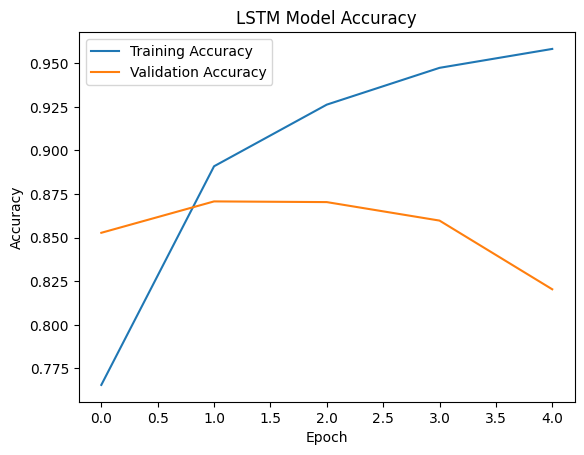

In [1]:
############
# LSTM for Text classification
#
###########
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

# Load IMDB dataset (keep top 10,000 frequent words)
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Make all reviews the same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# Build the LSTM model
model = Sequential()

# Embedding layer converts word numbers into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))

# LSTM layer for learning long-term text patterns
model.add(LSTM(64))

# Output layer for binary sentiment classification
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

# Plot training accuracy
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Model Accuracy")
plt.show()